DistilBERT

In [15]:
# библиотеки и setup
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import torch

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from configs.config import PROCESSED_DIR

import mlflow

from src.utils.mlflow_utils import setup_mlflow
from src.utils.mlflow_safe import safe_run

mlflow = setup_mlflow("sentiment_analysis")

MLflow URI: sqlite:///C:\Users\korobochka_sahara\dpo\dpo-ai\project\artifacts\mlflow\mlflow.db


In [16]:
# данные
train = pd.read_csv(PROCESSED_DIR / "train.csv")
test = pd.read_csv(PROCESSED_DIR / "test.csv")
train = train.sample(10000, random_state=42)

label_encoder = LabelEncoder()

train["label"] = label_encoder.fit_transform(
    train["sentiment"]
)

test["label"] = label_encoder.transform(
    test["sentiment"]
)

In [17]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [18]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [19]:
train_dataset = ReviewDataset(
    train["text"].values,
    train["label"].values,
    tokenizer
)

test_dataset = ReviewDataset(
    test["text"].values,
    test["label"].values,
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2406.90it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [22]:
def train_one_epoch():
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [23]:
def evaluate(model, loader, device):
    model.eval()

    preds, labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            y = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())
            labels.extend(y.cpu().numpy())

    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    return acc, f1, precision, recall, preds, labels

In [24]:
EPOCHS = 2

In [25]:
with safe_run("distilbert"):
    for epoch in range(EPOCHS):
        loss = train_one_epoch()
        acc, f1, precision, recall, preds, labels = evaluate(
            model,
            test_loader,
            device
        )
        print(
            f"Epoch {epoch}: loss={loss:.4f}, "
            f"acc={acc:.4f}, f1={f1:.4f}, "
            f"precision={precision:.4f}, recall={recall:.4f}"
        )

        mlflow.log_metrics({
            f"loss_epoch_{epoch}": loss,
            f"accuracy_epoch_{epoch}": acc,
            f"f1_epoch_{epoch}": f1,
            f"precision_epoch_{epoch}": precision,
            f"recall_epoch_{epoch}": recall
        })

    mlflow.log_params({
        "model": "DistilBERT",
        "epochs": EPOCHS,
        "lr": 2e-5,
        "batch_size": 16,
        "max_len": 64,
        "base_model": "distilbert-base-uncased"
    })
    
    final_acc, final_f1, final_precision, final_recall, preds, labels = evaluate(
        model,
        test_loader,
        device
    )

    mlflow.log_metrics({
        "accuracy": final_acc,
        "f1": final_f1,
        "precision": final_precision,
        "recall": final_recall
    })

    mlflow.pytorch.log_model(model, "model")

100%|██████████| 1250/1250 [09:53<00:00,  2.11it/s]


Epoch 0: loss=0.3081, acc=0.9070, f1=0.9081, precision=0.9210, recall=0.8955


100%|██████████| 1250/1250 [10:43<00:00,  1.94it/s]


Epoch 1: loss=0.1536, acc=0.9081, f1=0.9094, precision=0.9198, recall=0.8992


100%|██████████| 1250/1250 [12:06<00:00,  1.72it/s]
2026/05/15 15:32:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 15:32:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [26]:
runs = mlflow.search_runs()
runs[[
    "run_id",
    "metrics.f1",
    "metrics.accuracy",
    "params.model"
]].sort_values("metrics.f1", ascending=False)

,run_id,metrics.f1,metrics.accuracy,params.model
0,c7d74e8afb7545fc9978aa5b1fa67f32,0.909396,0.908132,DistilBERT
1,5783a87cd577450a9e6349eda1dd59e8,NaN,NaN,DistilBERT


In [27]:
from src.models.export_best_model import export_artifacts

export_artifacts(
    model=model,
    tokenizer=tokenizer,
    label_encoder=label_encoder
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.21it/s]

Artifacts exported successfully


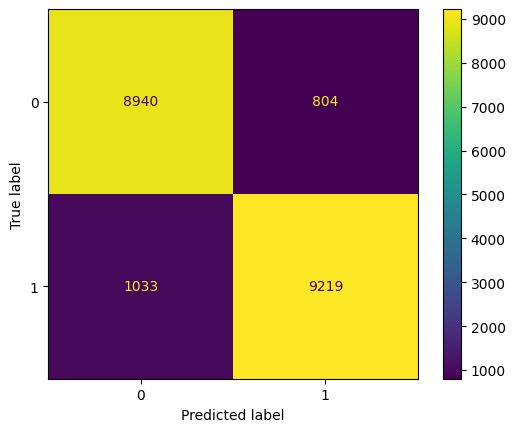

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from configs.config import ARTIFACTS_DIR

cm = confusion_matrix(labels, preds)

ConfusionMatrixDisplay(cm).plot()
plt.show()

cm_path = ARTIFACTS_DIR / "models/confusion_matrix_distilbert.png"
plt.savefig(cm_path)
plt.close()